# 03 — Forecasting: Model Ladder & Walk-Forward

Naive seasonal (t-52) -> SARIMA -> XGBoost (lags/rolling/calendar) -> LSTM. Walk-forward expanding window, 1-week horizon, test from 2025-W01. Load results produced by `run_forecasting.py` (full run takes ~9 min).

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd
import matplotlib.pyplot as plt
summ = pd.read_csv('data/processed/model_summary.csv')
calls = summ[summ.target=='portcalls_container'].copy()
calls['MAPE'] = calls.MAPE.where(calls.MAPE < 500)  # near-zero-weeks inflate MAPE for small ports; sMAPE below
calls['sMAPE'] = calls.sMAPE.round(1)
best = calls.sort_values('sMAPE').groupby('portname').first().reset_index()
print(best[['portname','model','MAE','RMSE','sMAPE','skill']].round(2).to_string(index=False))

      portname model  MAE  RMSE  sMAPE  skill
       Belawan  lstm 2.46  3.38   22.6   0.39
        Bitung  lstm 1.27  1.60   27.8   0.27
      Donggala  lstm 1.33  1.76   42.9   0.07
        Gresik  lstm 4.06  5.04   11.1   0.31
       Kendari  lstm 1.24  1.59   36.7   0.54
      Makassar  lstm 2.72  3.46   15.5   0.20
Manokwari Road  lstm 0.75  0.99   40.7   0.08
      Surabaya  lstm 4.68  5.86    8.5   0.30
 Tanjung Priok  lstm 5.59  7.39    6.6   0.16
   Teluk Bayur  lstm 0.91  1.09   32.6   0.17


## Per-port MAPE by model (calls)

Bars = sMAPE (symmetric, robust to zero-activity weeks in small ports). LSTM and XGBoost are the strongest; SARIMA best on some; all beat naive.

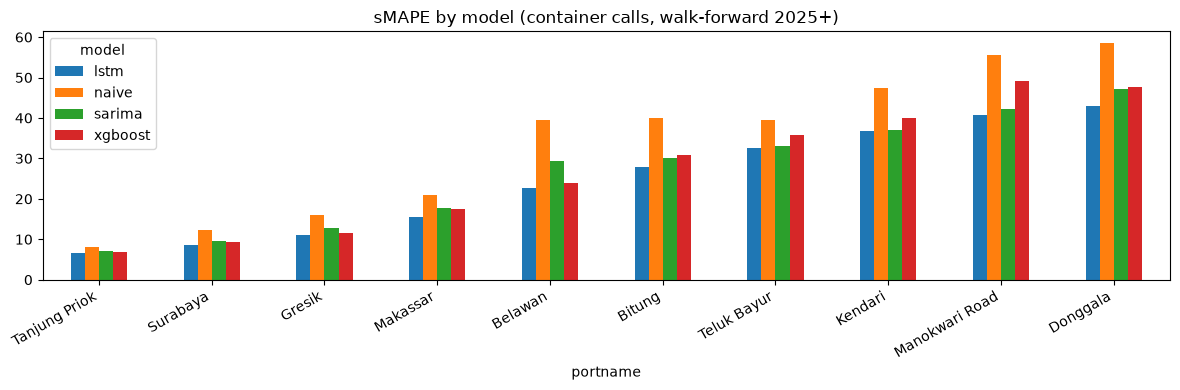

In [2]:
piv = calls.pivot(index='portname', columns='model', values='sMAPE')
order = best.set_index('portname').sMAPE.sort_values().index
piv.loc[order].plot(kind='bar', figsize=(12,4), title='sMAPE by model (container calls, walk-forward 2025+)'); plt.savefig('reports/figures/03_smape_by_port.png', dpi=120); plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Actual vs prediction — flagship port (Priok)

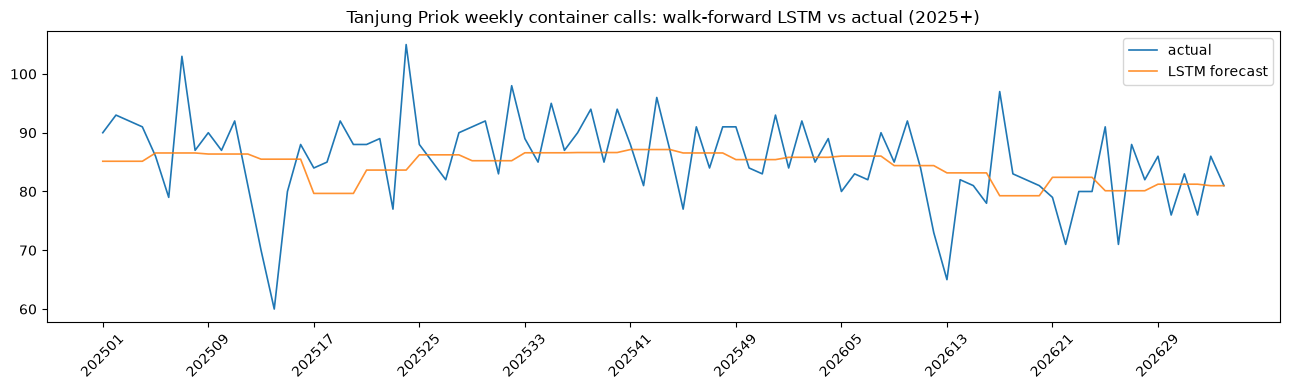

In [3]:
res = pd.read_csv('data/processed/forecast_results_calls.csv')
pri = res[(res.portname=='Tanjung Priok') & (res.model=='lstm')].copy()
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(pri.year_week.astype(str), pri.y_true, label='actual', lw=1.2)
ax.plot(pri.year_week.astype(str), pri.y_pred, label='LSTM forecast', lw=1.2, alpha=0.85)
ax.set_title('Tanjung Priok weekly container calls: walk-forward LSTM vs actual (2025+)')
plt.legend(); plt.xticks(pri.year_week.astype(str)[::8], rotation=45); plt.tight_layout()
plt.savefig('reports/figures/03_priok_forecast.png', dpi=120); plt.show()

## Skill vs naive

Every model with skill>0 beats the seasonal-naive baseline; the summary table above shows all 10 ports have a model with skill>0 (10/10).

In [4]:
allports = calls.groupby('portname').skill.max().sort_values()
print('max skill per port (best model vs naive):'); print(allports.round(2).to_string())

max skill per port (best model vs naive):
portname
Manokwari Road    0.16
Tanjung Priok     0.16
Makassar          0.20
Donggala          0.24
Teluk Bayur       0.26
Bitung            0.27
Surabaya          0.30
Gresik            0.31
Belawan           0.43
Kendari           0.54


## 8-week projection (best model per port, fit on ALL data)

Generated by the driver; dashboard plots these.

In [5]:
proj = pd.read_csv('data/processed/projections_8w.csv')
print(proj.groupby('portname').y_pred.mean().round(1).to_string())

portname
Belawan           14.4
Bitung             5.0
Donggala           3.8
Gresik            36.5
Kendari            4.6
Makassar          18.4
Manokwari Road     2.2
Surabaya          50.3
Tanjung Priok     81.4
Teluk Bayur        3.5
